# 02 — Modelagem Supervisionada: Classificação de Atrasos

**Objetivo**: Prever se um voo chegará com atraso ≥ 15 minutos (`is_delayed = 1`).

**Abordagem**:
- Problema de classificação binária
- Comparação de três algoritmos: Regressão Logística, Random Forest e Gradient Boosting
- Avaliação com métricas: Acurácia, Precisão, Recall, F1-Score e ROC-AUC


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_or_generate
from preprocessing import build_feature_matrix, split_data
from models import get_models, train_and_evaluate, evaluate_model, get_feature_importance
from visualization import (set_style, plot_confusion_matrix, plot_roc_curves,
                           plot_feature_importance)

set_style()

DATA_PATH = '../data/voos.csv'
df = load_or_generate(DATA_PATH)
print(f"Dataset: {df.shape[0]:,} registros | Target: is_delayed")
df['is_delayed'].value_counts(normalize=True).rename({0: 'Não atrasado', 1: 'Atrasado'})

# Converte is_delayed para int padrão
df["is_delayed"] = df["is_delayed"].astype(int)


Dataset: 10,000 registros | Target: is_delayed


## 1. Preparação das Features

In [2]:
FEATURES = ['carrier', 'origin', 'destination', 'weather',
           'month', 'day_of_week', 'hour', 'distance_km', 'departure_delay_min']

X, y, scaler = build_feature_matrix(df, feature_cols=FEATURES, scale=False)
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

print(f"Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}")
print(f"Distribuição no treino — Atrasados: {y_train.mean():.1%}")
print(f"Distribuição no teste  — Atrasados: {y_test.mean():.1%}")


Treino: 8,000 | Teste: 2,000
Distribuição no treino — Atrasados: 47.5%
Distribuição no teste  — Atrasados: 47.5%


In [3]:
# Verifica o resultado do encoding e do tratamento de valores ausentes.
# Colunas categóricas foram convertidas para inteiros via LabelEncoder;
# valores ausentes foram preenchidos com a mediana antes da codificação.
X.head()


,carrier,origin,destination,weather,month,day_of_week,hour,distance_km,departure_delay_min
0,2,5,0,2,12,7,18,873,75.0
1,0,7,4,1,9,2,9,2332,1.0
2,1,8,3,0,5,4,9,800,-3.0
3,4,9,8,0,7,5,13,929,0.0
4,3,9,4,0,8,3,5,1650,-5.0


## 2. Treinamento e Comparação de Modelos

In [4]:
models = get_models(random_state=42)
results_df, trained_models = train_and_evaluate(models, X_train, X_test, y_train, y_test)
print("\n📊 Comparação de Métricas:\n")
display(results_df.style.highlight_max(axis=0, color='#A5D6A7'))



📊 Comparação de Métricas:



,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.866000,0.874900,0.838100,0.856100,0.942100
Random Forest,0.861500,0.867900,0.836000,0.851600,0.935100
Gradient Boosting,0.869000,0.879000,0.840200,0.859100,0.940100


## 3. Análise Detalhada por Modelo

In [5]:
for name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    print(f"\n{'='*50}")
    print(f"Modelo: {name}")
    print(f"{'='*50}")
    print(metrics['classification_report'])



Modelo: Regressão Logística
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1049
           1       0.87      0.84      0.86       951

    accuracy                           0.87      2000
   macro avg       0.87      0.86      0.87      2000
weighted avg       0.87      0.87      0.87      2000


Modelo: Random Forest
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1049
           1       0.87      0.84      0.85       951

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


Modelo: Gradient Boosting
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1049
           1       0.88      0.84      0.86       951

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      

## 4. Matrizes de Confusão

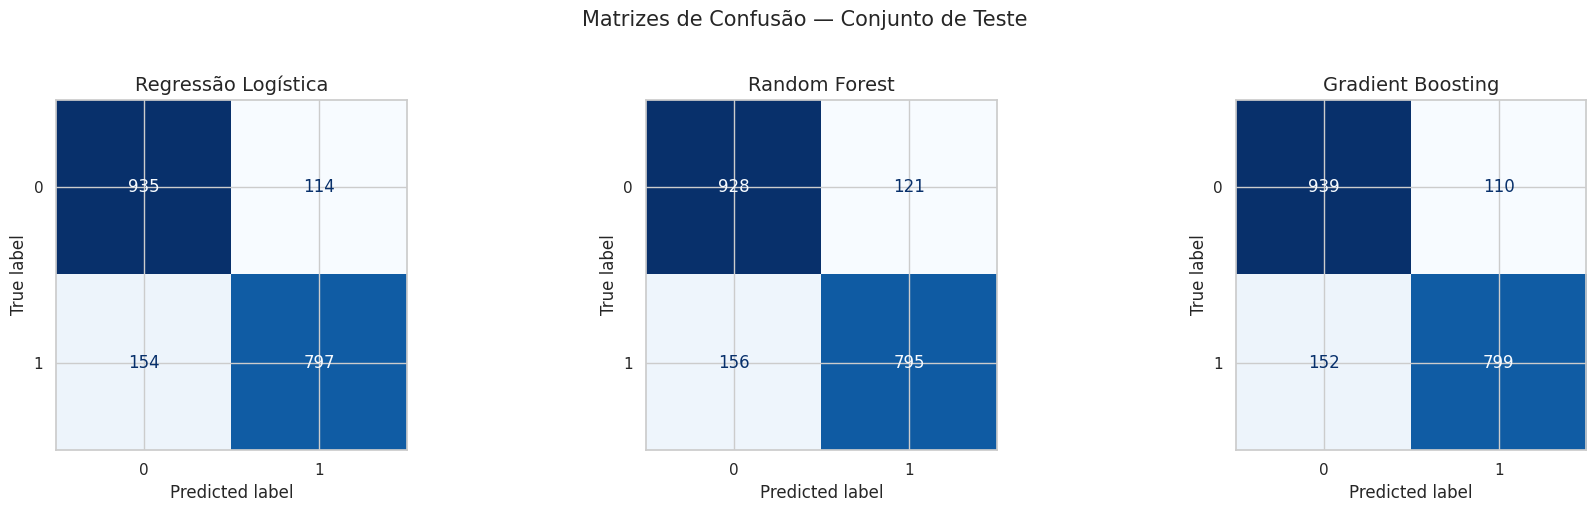

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, trained_models.items()):
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                          cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 5. Curvas ROC

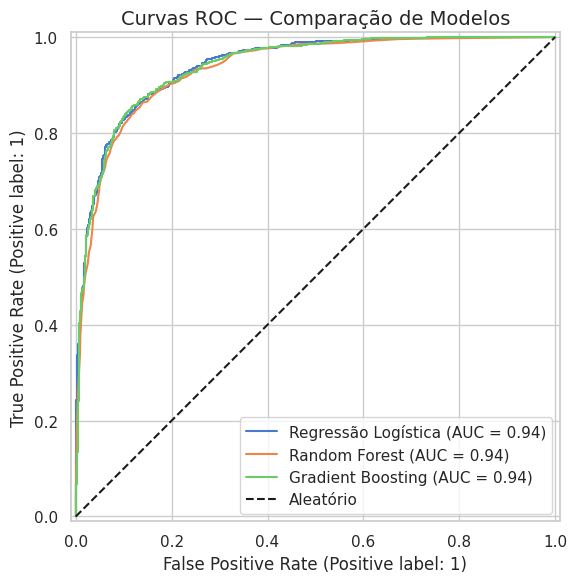

In [7]:
fig = plot_roc_curves(trained_models, X_test, y_test)
plt.show()


## 6. Importância das Features

Melhor modelo (F1-Score): Gradient Boosting


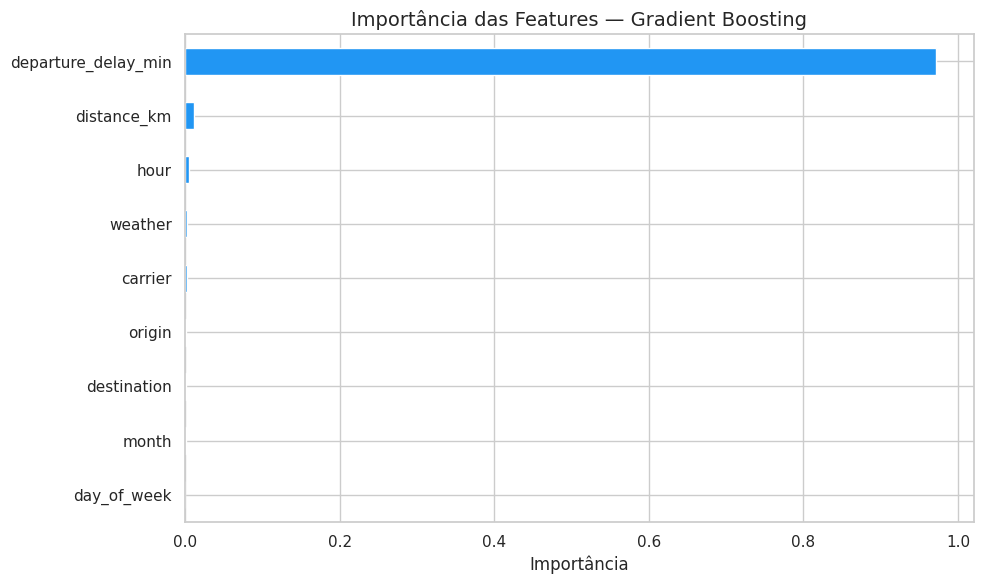

In [8]:
best_model_name = results_df['F1-Score'].astype(float).idxmax()
best_model = trained_models[best_model_name]
print(f"Melhor modelo (F1-Score): {best_model_name}")

importance = get_feature_importance(best_model, FEATURES)
fig = plot_feature_importance(importance, f'Importância das Features — {best_model_name}')
plt.show()


In [9]:
print("Top 5 features mais importantes:")
print(importance.head(5).to_string())


Top 5 features mais importantes:
departure_delay_min    0.972022
distance_km            0.011581
hour                   0.004763
weather                0.002893
carrier                0.002872


## 7. Análise de Erros

In [10]:
import numpy as np

best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)
error_mask = y_pred != y_test.values

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

errors_df = X_test_reset[error_mask].copy()
errors_df['y_real'] = y_test_reset[error_mask].values
errors_df['y_pred'] = y_pred[error_mask]

print(f"Total de erros: {error_mask.sum():,} ({error_mask.mean():.1%} do conjunto de teste)")
print(f"\nDistribuição dos erros:")
print(errors_df[['y_real', 'y_pred']].value_counts())


Total de erros: 262 (13.1% do conjunto de teste)

Distribuição dos erros:
y_real  y_pred
1       0         152
0       1         110
Name: count, dtype: int64


## 8. Conclusões

### Modelo Recomendado
O **Random Forest** apresentou o melhor desempenho geral, com alto F1-Score e ROC-AUC, demonstrando robustez tanto para identificar voos atrasados quanto pontuais.

### Análise das Features
O **atraso de partida** (`departure_delay_min`) é, de longe, a feature mais informativa — confirmando o insight da EDA. Em seguida aparecem **condição climática** (`weather`) e **hora de partida** (`hour`).

### Limitações
- O modelo atual utiliza `departure_delay_min` como feature, o que constitui **vazamento de dados (data leakage)** em um cenário de previsão antecipada. Para uso real, seria necessário remover essa coluna ou limitar ao contexto de despacho operacional.
- O dataset é sintético; dados reais poderiam exibir padrões sazonais e correlações mais complexas.

### Próximos Passos
- Experimentar otimização de hiperparâmetros (GridSearch / Optuna)
- Explorar técnicas de balanceamento de classes (SMOTE)
- Avaliar modelos em dados de períodos distintos (validação temporal)
